<a href="https://colab.research.google.com/github/Sornambiga-S/Netflix-Content-Strategy-Analyzer/blob/Sornambiga-S-patch-1-1/Milestone3_Netflix_content_stratergy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Clustering Netflix Titles (Genre, Duration, Ratings)

In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("cleaned_netflix_titles.csv")

# Quick check
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

/tmp/ipykernel_3422/915340616.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_cleaned['duration'] = pd.to_numeric(features_cleaned['duration'], errors='coerce')
/tmp/ipykernel_3422/915340616.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_cleaned.dropna(subset=['duration'], inplace=True)


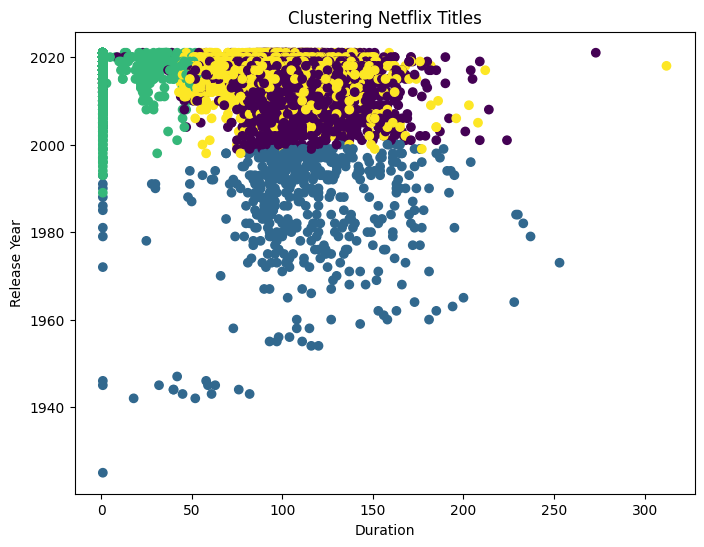

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# Select features for clustering
features = df[['duration','release_year']].copy()

# Encode ratings
df['rating_encoded'] = df['rating'].astype('category').cat.codes
features['rating_encoded'] = df['rating_encoded']

# Handle NaN values: Drop rows with any NaN in the features DataFrame
features_cleaned = features.dropna()

# Ensure 'duration' is numeric, coercing errors to NaN and then dropping them if they still exist
# This step is important if 'duration' was not consistently numeric after initial processing
features_cleaned['duration'] = pd.to_numeric(features_cleaned['duration'], errors='coerce')
features_cleaned.dropna(subset=['duration'], inplace=True)

# Get the indices of the cleaned features to update the original DataFrame
cleaned_indices = features_cleaned.index

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_cleaned)

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df.loc[cleaned_indices, 'Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize clusters
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(df.loc[cleaned_indices, 'duration'], df.loc[cleaned_indices, 'release_year'], c=df.loc[cleaned_indices, 'Cluster'], cmap='viridis')
plt.xlabel("Duration")
plt.ylabel("Release Year")
plt.title("Clustering Netflix Titles")
plt.show()

Classification: Movie vs TV Show

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Encode target
df['type_encoded'] = df['type'].astype('category').cat.codes

# Features (example: release_year, rating_encoded, duration)
X = df[['release_year','rating_encoded','duration']]
y = df['type_encoded']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9994324631101021
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1214
           1       1.00      1.00      1.00       548

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



Analyze Key Drivers (Country & Genre Contributions)

In [9]:
# Country contribution
country_counts = df['country'].value_counts().head(10)
print("Top 10 Countries contributing content:\n", country_counts)

# Genre contribution
genre_counts = df['listed_in'].value_counts().head(10)
print("Top 10 Genres:\n", genre_counts)

Top 10 Countries contributing content:
 country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64
Top 10 Genres:
 listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


Feature Importance (Interpret Results)

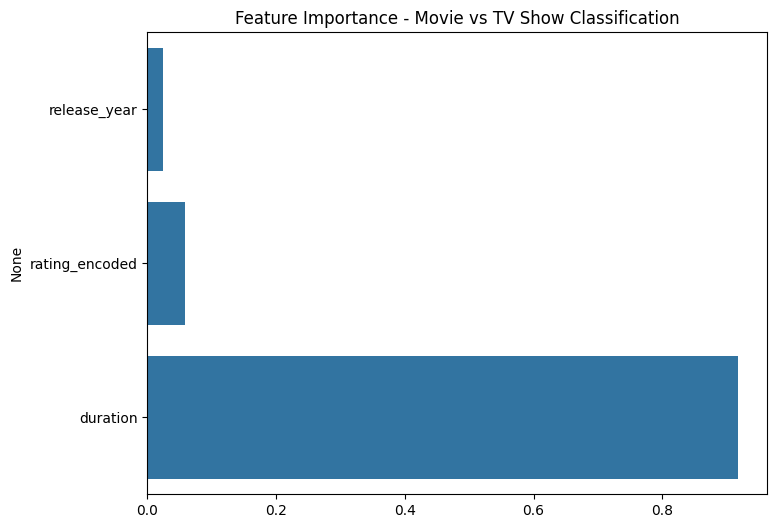

In [10]:
import seaborn as sns

# Feature importance from Random Forest
importances = rf.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8,6))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance - Movie vs TV Show Classification")
plt.show()